# Consumer Review analysis

## RO1: Identify the overall positive and negative sentiments for each product category.

In [4]:
import pandas as pd
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load the dataset
df_file = os.path.join('.', 'product_review_dataset.csv')
df = pd.read_csv(df_file)
df.head()


,Title,Review,Cons_rating,Cloth_class,Materials,Construction,Color,Finishing,Durability
0,NaN,Absolutely wonderful - silky and sexy and comf...,4.0,Intimates,0.0,0.0,0.0,1.0,0.0
1,NaN,Love this dress! it's sooo pretty. i happene...,5.0,Dresses,0.0,1.0,0.0,0.0,0.0
2,Some major design flaws,I had such high hopes for this dress and reall...,3.0,Dresses,0.0,0.0,0.0,1.0,0.0
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5.0,Pants,0.0,0.0,0.0,0.0,0.0
4,Flattering shirt,This shirt is very flattering to all due to th...,5.0,Blouses,0.0,1.0,0.0,0.0,0.0


In [5]:
df = df.dropna()


In [6]:
df.head()

,Title,Review,Cons_rating,Cloth_class,Materials,Construction,Color,Finishing,Durability
2,Some major design flaws,I had such high hopes for this dress and reall...,3.0,Dresses,0.0,0.0,0.0,1.0,0.0
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5.0,Pants,0.0,0.0,0.0,0.0,0.0
4,Flattering shirt,This shirt is very flattering to all due to th...,5.0,Blouses,0.0,1.0,0.0,0.0,0.0
5,Not for the very petite,"I love tracy reese dresses, but this one is no...",2.0,Dresses,0.0,1.0,1.0,0.0,0.0
6,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5.0,Knits,0.0,0.0,1.0,0.0,0.0


In [7]:
unique_vals = df['Cloth_class'].unique()
unique_vals

<StringArray>
[   'Dresses',      'Pants',    'Blouses',      'Knits',  'Intimates',
  'Outerwear',     'Lounge',   'Sweaters',     'Skirts', 'Fine gauge',
      'Sleep',    'Jackets',       'Swim',      'Trend',      'Jeans',
     'Shorts',    'Legwear',   'Layering',     'Blazer',     'Shirts',
      'Suits',      'Dress']
Length: 22, dtype: str

In [8]:
# Group reviews by Cloth_class
df['Review'] = df['Review'].astype(str)
df_product_grp = df.groupby('Cloth_class')['Review'].apply(lambda x: ' '.join(x)).reset_index()
df_product_grp

,Cloth_class,Review
0,Blazer,After this item was cleaned the dye faded onto...
1,Blouses,This shirt is very flattering to all due to th...
2,Dress,I love this dress so much! I got it for an out...
3,Dresses,I had such high hopes for this dress and reall...
4,Fine gauge,This poncho is so cute i love the plaid check ...
5,Intimates,Bought the black xs to go under the larkspur m...
6,Jackets,"Nice vest, pretty olive color, hangs nice but...."
7,Jeans,"I love paige brand pants-they are soft, comfor..."
8,Knits,I aded this in my basket at hte last mintue to...
9,Layering,"I love this dress. i'm 5'8"" and it fits me exa..."


# Develop word clouds for each product category to visualize the most frequent words in positive and negative reviews.

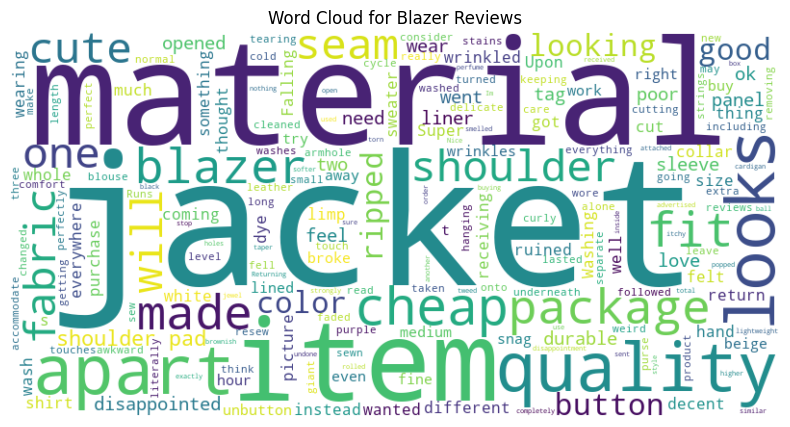

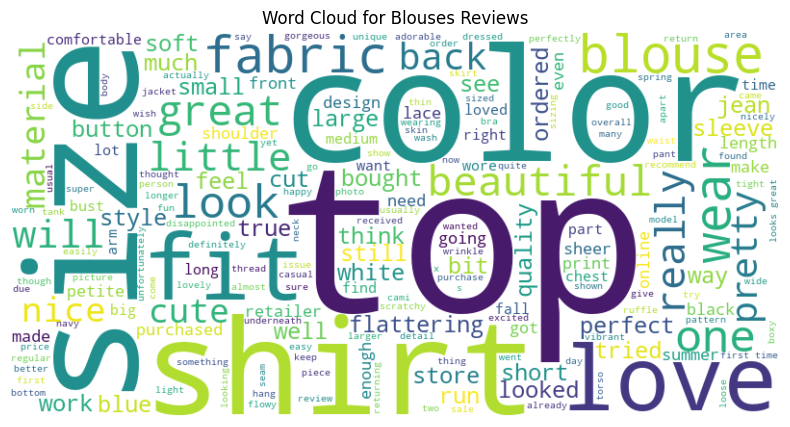

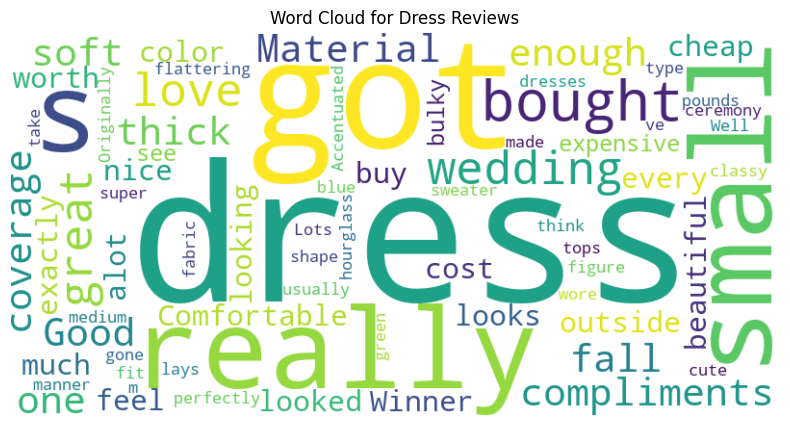

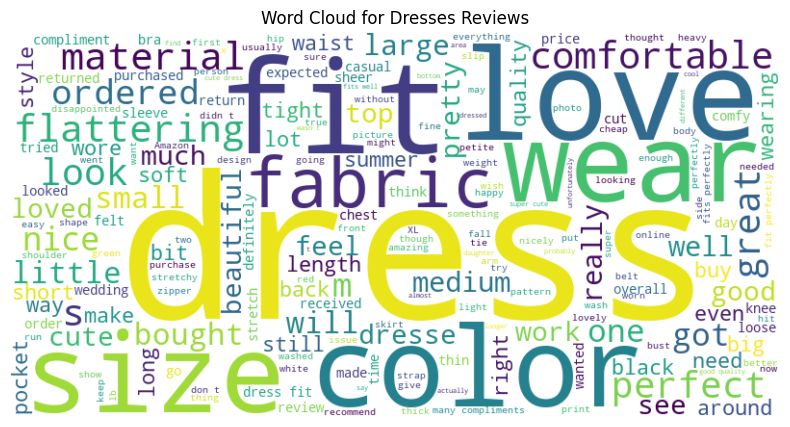

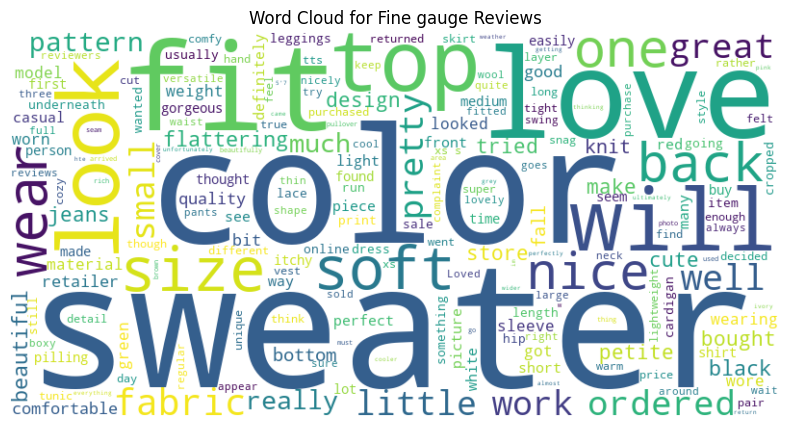

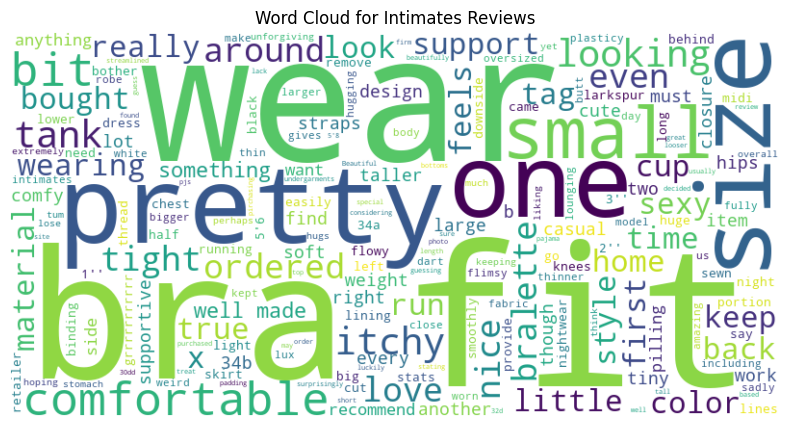

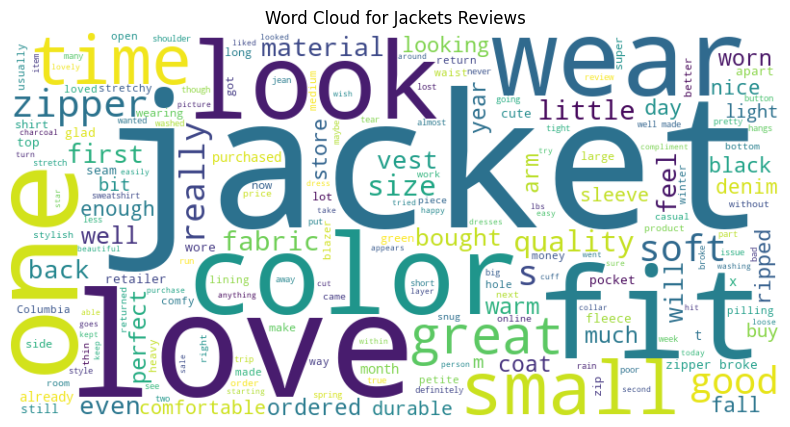

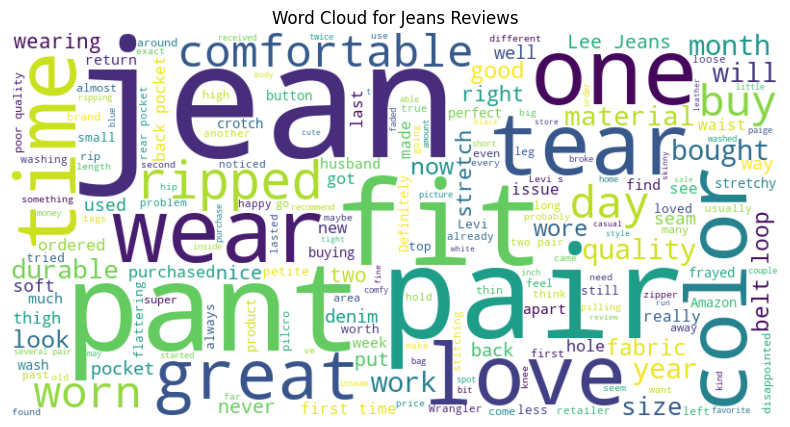

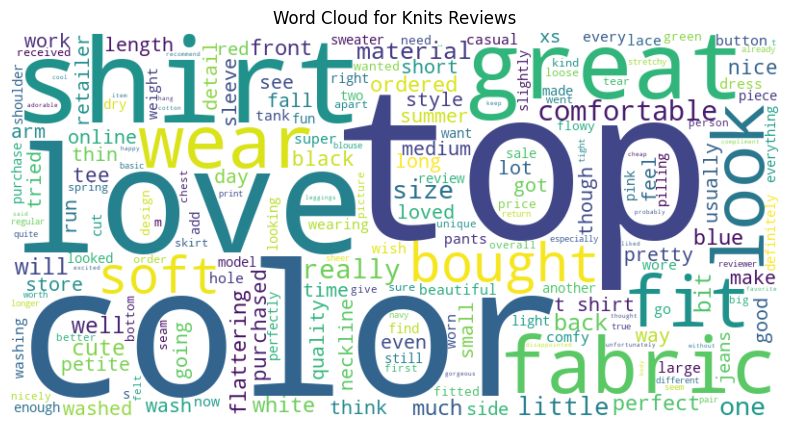

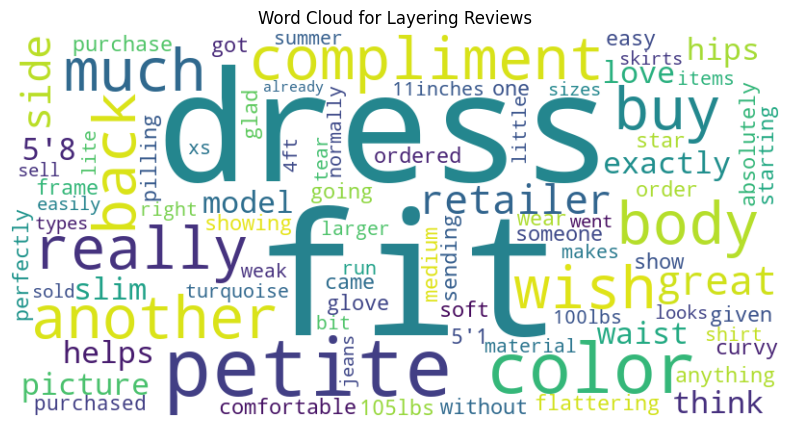

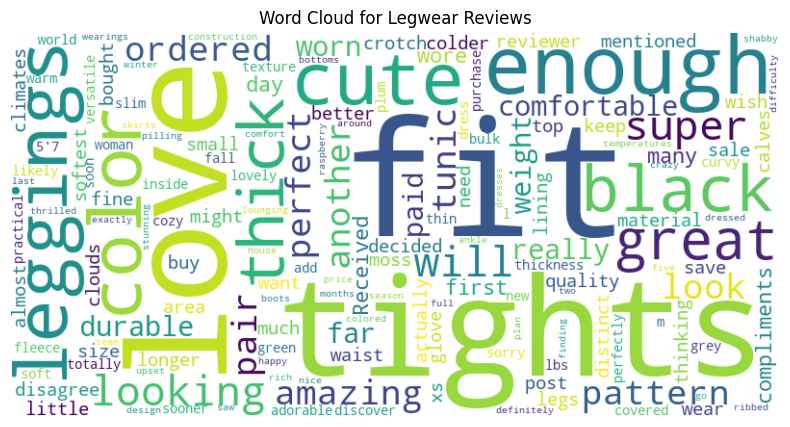

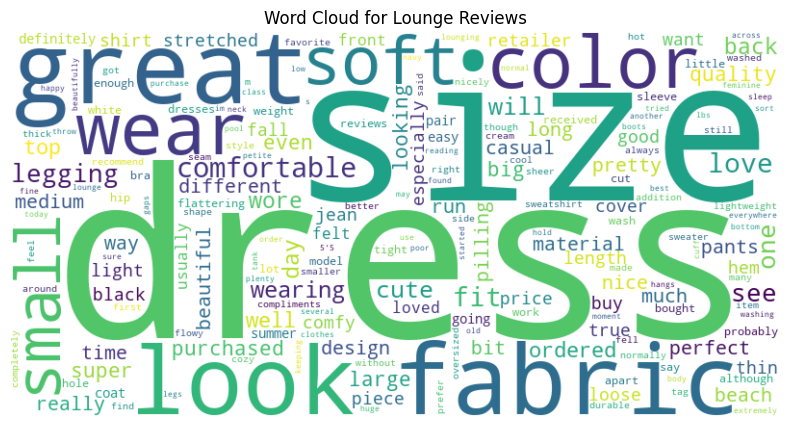

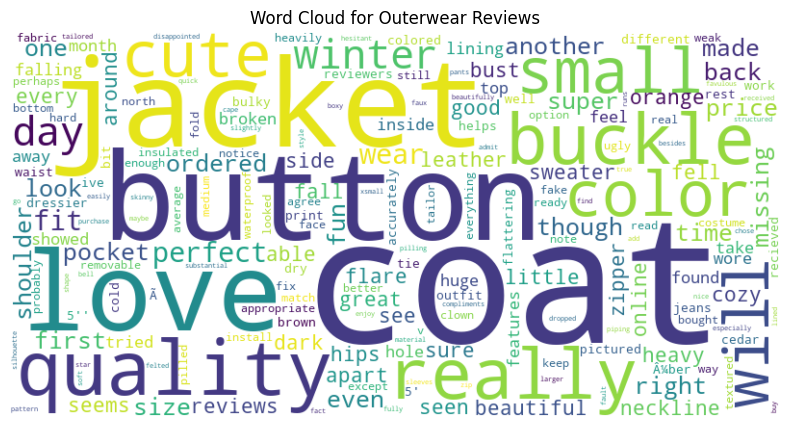

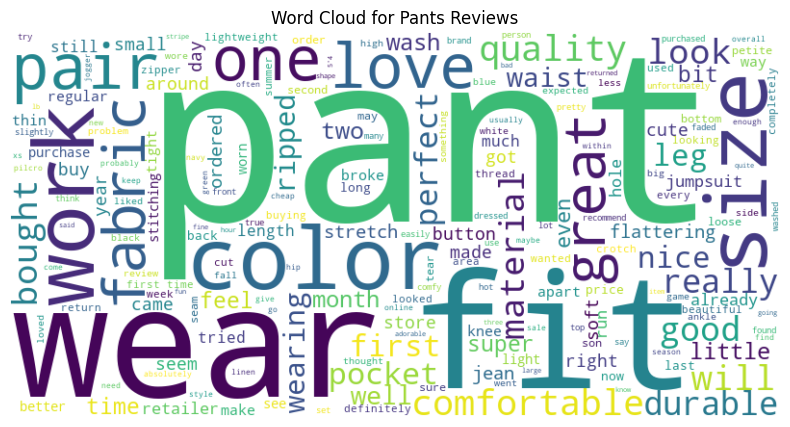

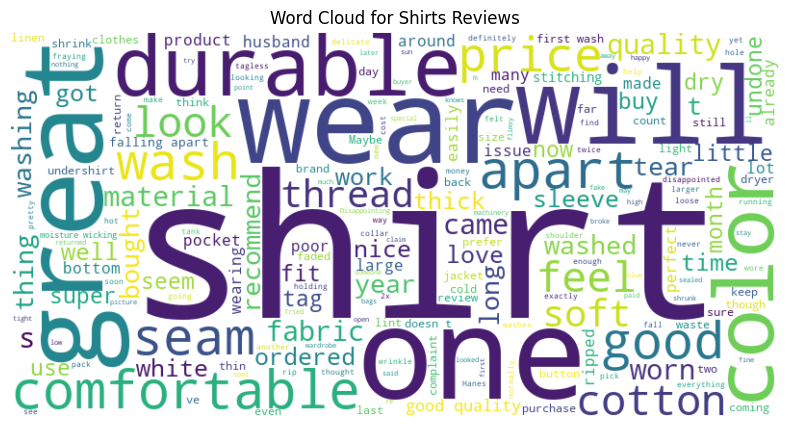

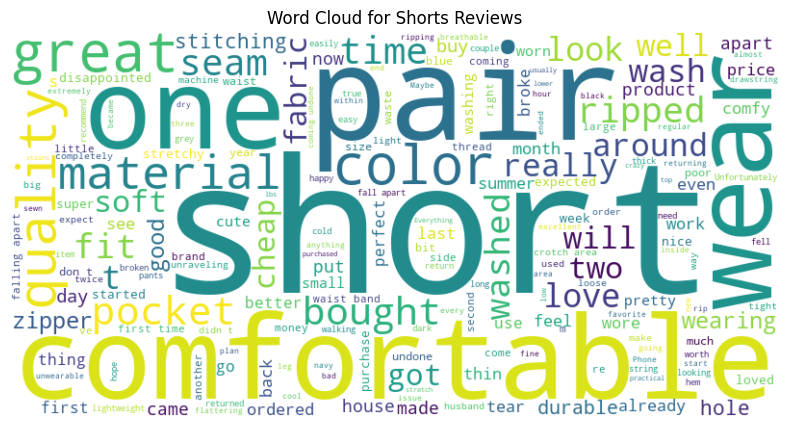

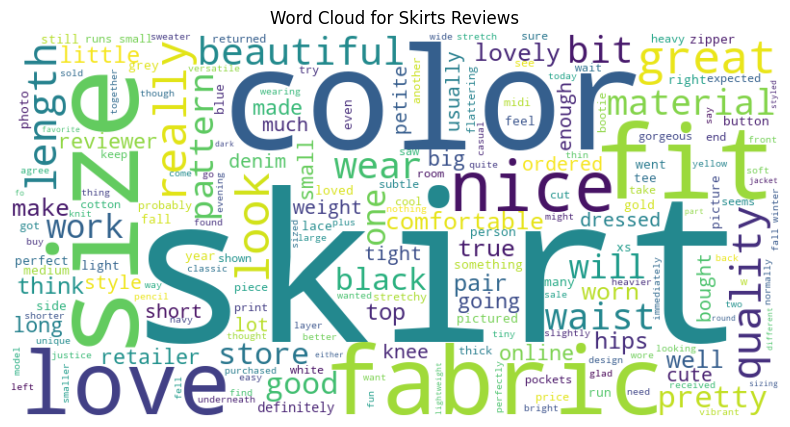

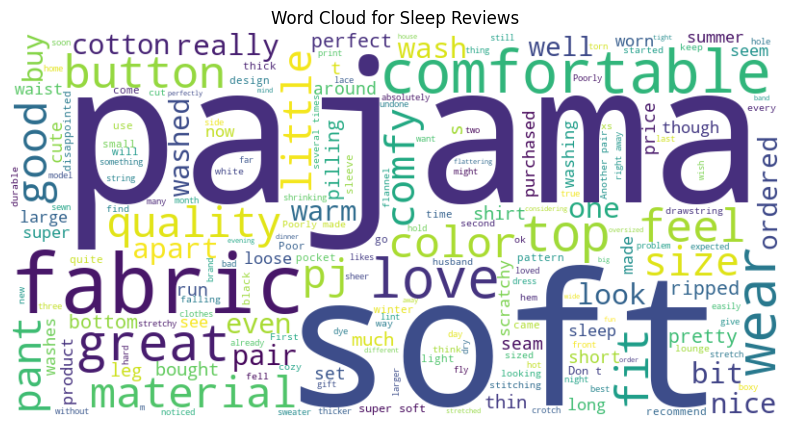

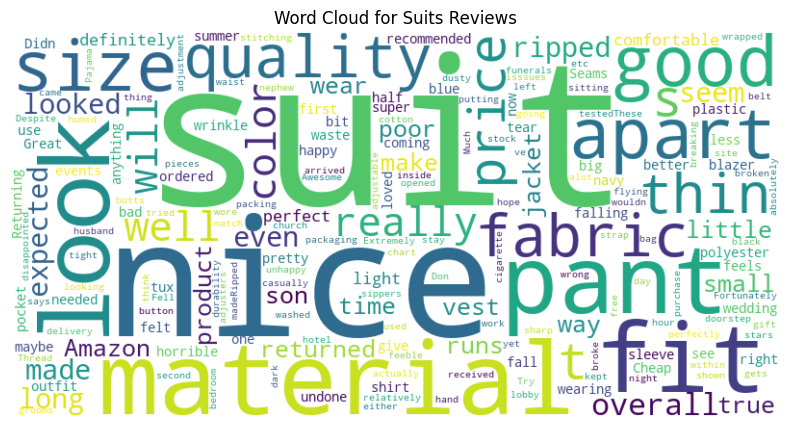

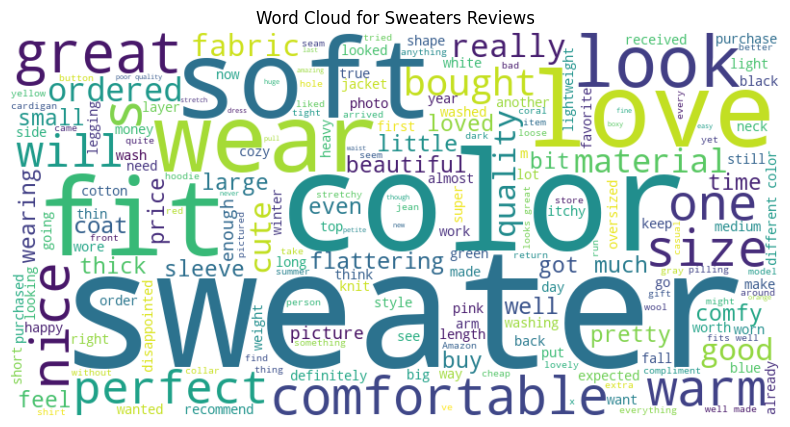

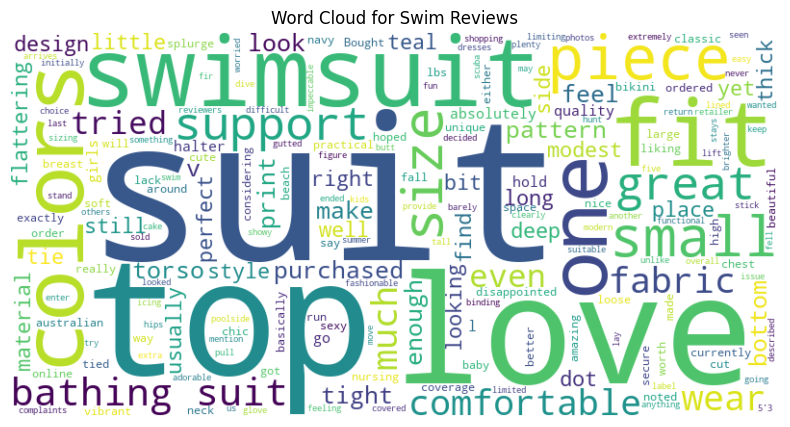

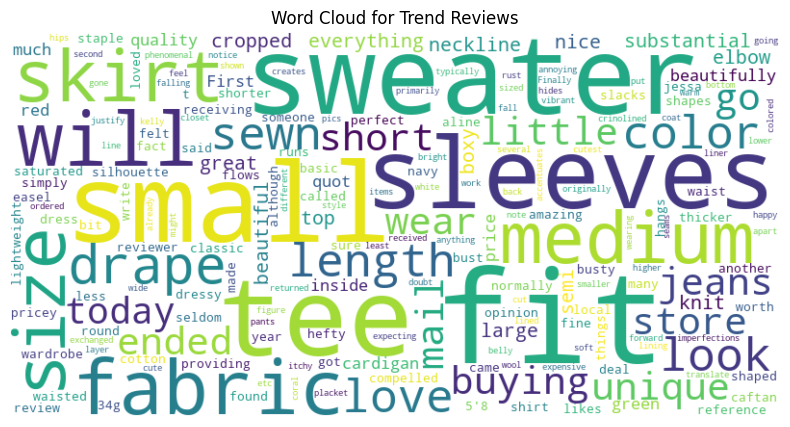

In [9]:
for category in df_product_grp['Cloth_class']:
    reviews = df_product_grp[df_product_grp['Cloth_class'] == category]['Review'].values[0]

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(reviews)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {category} Reviews')
    plt.show()

Sentiment analysis using TextBlob

In [10]:
#get sentiment polarity for each review and add it as a new column
from textblob import TextBlob
df_product_grp['Sentiment_Polarity'] = df_product_grp['Review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_product_grp.head()

,Cloth_class,Review,Sentiment_Polarity
0,Blazer,After this item was cleaned the dye faded onto...,0.107249
1,Blouses,This shirt is very flattering to all due to th...,0.231695
2,Dress,I love this dress so much! I got it for an out...,0.234954
3,Dresses,I had such high hopes for this dress and reall...,0.248658
4,Fine gauge,This poncho is so cute i love the plaid check ...,0.205268
